In [1]:
import scipy.io
import numpy as np
import glob
import os

# Load the dataset — tất cả parts
data_path = '/kaggle/input/datasets/mkachuee/BloodPressureDataset'
part_files = sorted(glob.glob(f'{data_path}/part_*.mat'))
print(f"Tìm thấy {len(part_files)} parts: {[os.path.basename(f) for f in part_files]}")


Tìm thấy 12 parts: ['part_1.mat', 'part_10.mat', 'part_11.mat', 'part_12.mat', 'part_2.mat', 'part_3.mat', 'part_4.mat', 'part_5.mat', 'part_6.mat', 'part_7.mat', 'part_8.mat', 'part_9.mat']


In [2]:
# Initialize lists to store PPG, ECG, and ABP signals
ppg, ecg, abp = [], [], []
sample_size = 250


Cell 2 — Load toàn bộ parts và tách segments

In [3]:
# Split data into smaller samples — load ALL parts
# + LỌC dữ liệu lỗi + TRACK group_ids cho patient-level split

group_ids = []       # group_id cho mỗi segment (dùng để split)
global_record_idx = 0  # đếm record toàn cục

# Thống kê filtering
stats = {'nan_inf': 0, 'flat': 0, 'bp_range': 0, 'ppg_amp': 0, 'kept': 0}

for part_idx, part_file in enumerate(part_files):
    print(f"\n📁 Loading {os.path.basename(part_file)} ({part_idx + 1}/{len(part_files)})...")
    sample_mat = scipy.io.loadmat(part_file)['p']
    n_records = sample_mat.shape[1]
    print(f"   → {n_records} records trong part này")

    count_before = len(ppg)

    for i in range(n_records):
        try:
            temp_mat = sample_mat[0, i]
            total_len = temp_mat.shape[1]

            for j in range(total_len // sample_size):
                seg_ppg = temp_mat[0, j*sample_size:(j+1)*sample_size]
                seg_abp = temp_mat[1, j*sample_size:(j+1)*sample_size]
                seg_ecg = temp_mat[2, j*sample_size:(j+1)*sample_size]

                # === LỌC 1: NaN / Inf ===
                if (np.isnan(seg_ppg).any() or np.isinf(seg_ppg).any() or
                    np.isnan(seg_abp).any() or np.isinf(seg_abp).any() or
                    np.isnan(seg_ecg).any() or np.isinf(seg_ecg).any()):
                    stats['nan_inf'] += 1
                    continue

                # === LỌC 2: Tín hiệu phẳng (std ≈ 0) ===
                if np.std(seg_ppg) < 1e-6 or np.std(seg_ecg) < 1e-6 or np.std(seg_abp) < 1e-6:
                    stats['flat'] += 1
                    continue

                # === LỌC 3: BP range sinh lý ===
                sbp_val = seg_abp.max()
                dbp_val = seg_abp.min()
                if not (50 <= sbp_val <= 250 and 30 <= dbp_val <= 150 and sbp_val > dbp_val + 10):
                    stats['bp_range'] += 1
                    continue

                # === LỌC 4: PPG amplitude hợp lý ===
                ppg_ptp = np.ptp(seg_ppg)  # peak-to-peak
                if ppg_ptp < 1e-4 or ppg_ptp > 1e6:
                    stats['ppg_amp'] += 1
                    continue

                # === PASS — giữ lại ===
                ppg.append(seg_ppg)
                abp.append(seg_abp)
                ecg.append(seg_ecg)
                group_ids.append(global_record_idx)  # cùng record = cùng group
                stats['kept'] += 1

        except Exception as e:
            print(f"   ⚠️ Lỗi tại record {i}: {e}")
            continue

        global_record_idx += 1  # tăng sau mỗi record

    count_after = len(ppg)
    print(f"   → Tạo được {count_after - count_before} segments")

ppg = np.array(ppg, dtype=np.float32).reshape(-1, sample_size)
ecg = np.array(ecg, dtype=np.float32).reshape(-1, sample_size)
abp = np.array(abp, dtype=np.float32).reshape(-1, sample_size)
group_ids = np.array(group_ids)

# === In thống kê ===
total_checked = sum(stats.values())
print(f"\n{'='*55}")
print(f"  📊 THỐNG KÊ LỌC DATA")
print(f"{'='*55}")
print(f"  Tổng segments kiểm tra : {total_checked}")
print(f"  ❌ NaN/Inf             : {stats['nan_inf']}")
print(f"  ❌ Tín hiệu phẳng     : {stats['flat']}")
print(f"  ❌ BP ngoài range      : {stats['bp_range']}")
print(f"  ❌ PPG amplitude lỗi   : {stats['ppg_amp']}")
print(f"  ✅ Giữ lại             : {stats['kept']} ({stats['kept']/total_checked*100:.1f}%)")
print(f"{'='*55}")
print(f"\n  PPG shape : {ppg.shape}")
print(f"  ECG shape : {ecg.shape}")
print(f"  ABP shape : {abp.shape}")
print(f"  Groups    : {len(np.unique(group_ids))} records")

# === Kiểm tra cuối ===
assert not np.isnan(ppg).any(), "❌ PPG chứa NaN!"
assert not np.isnan(ecg).any(), "❌ ECG chứa NaN!"
assert not np.isnan(abp).any(), "❌ ABP chứa NaN!"
print("\n✅ Data sạch — không có NaN/Inf")



📁 Loading part_1.mat (1/12)...
   → 1000 records trong part này
   → Tạo được 128179 segments

📁 Loading part_10.mat (2/12)...
   → 1000 records trong part này
   → Tạo được 118551 segments

📁 Loading part_11.mat (3/12)...
   → 1000 records trong part này
   → Tạo được 120412 segments

📁 Loading part_12.mat (4/12)...
   → 1000 records trong part này
   → Tạo được 98677 segments

📁 Loading part_2.mat (5/12)...
   → 1000 records trong part này
   → Tạo được 112089 segments

📁 Loading part_3.mat (6/12)...
   → 1000 records trong part này
   → Tạo được 90638 segments

📁 Loading part_4.mat (7/12)...
   → 1000 records trong part này
   → Tạo được 122616 segments

📁 Loading part_5.mat (8/12)...
   → 1000 records trong part này
   → Tạo được 130779 segments

📁 Loading part_6.mat (9/12)...
   → 1000 records trong part này
   → Tạo được 127737 segments

📁 Loading part_7.mat (10/12)...
   → 1000 records trong part này
   → Tạo được 61928 segments

📁 Loading part_8.mat (11/12)...
   → 1000 record

Cell 3 — Vẽ tín hiệu mẫu

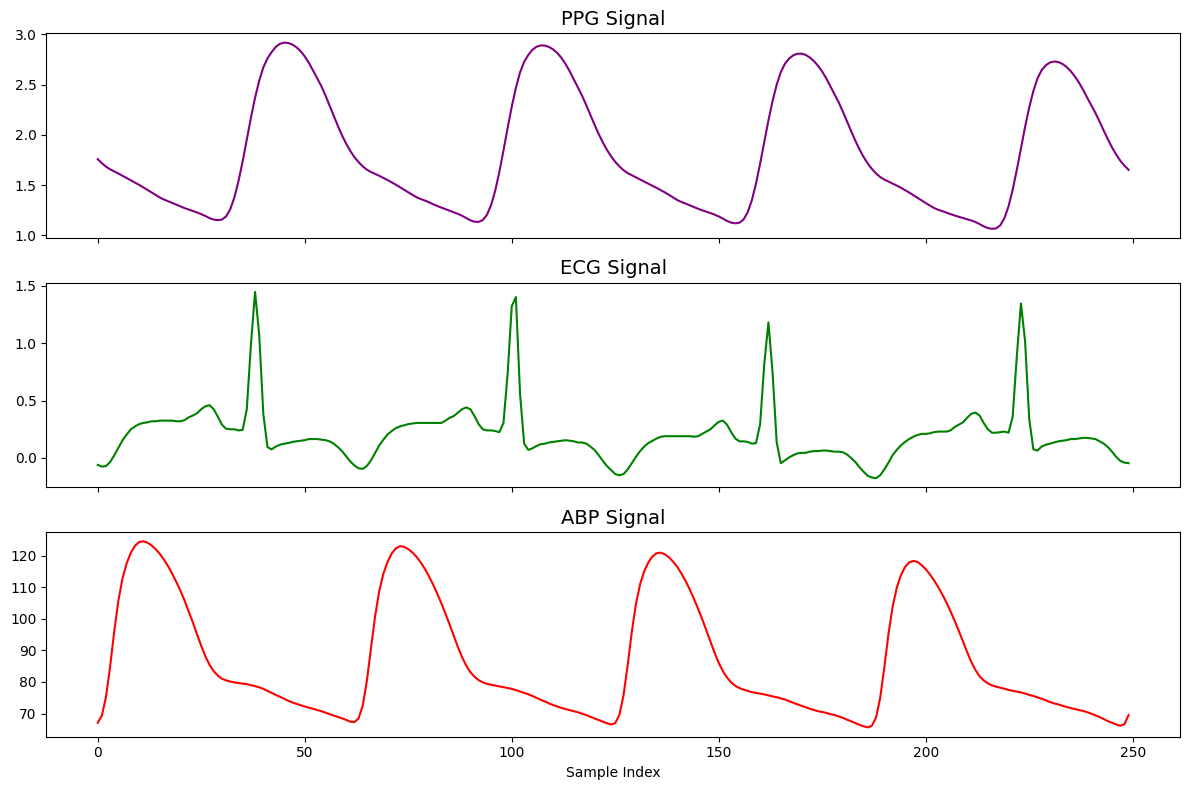

In [4]:
import matplotlib.pyplot as plt

# Plot PPG, ECG, and ABP signals
idx = 0
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax[0].plot(ppg[idx], color='purple')
ax[0].set_title("PPG Signal", fontsize=14)

ax[1].plot(ecg[idx], color='green')
ax[1].set_title("ECG Signal", fontsize=14)

ax[2].plot(abp[idx], color='red')
ax[2].set_title("ABP Signal", fontsize=14)

plt.xlabel("Sample Index")
plt.tight_layout()
plt.show()


Cell 4 — Phân phối SBP và DBP

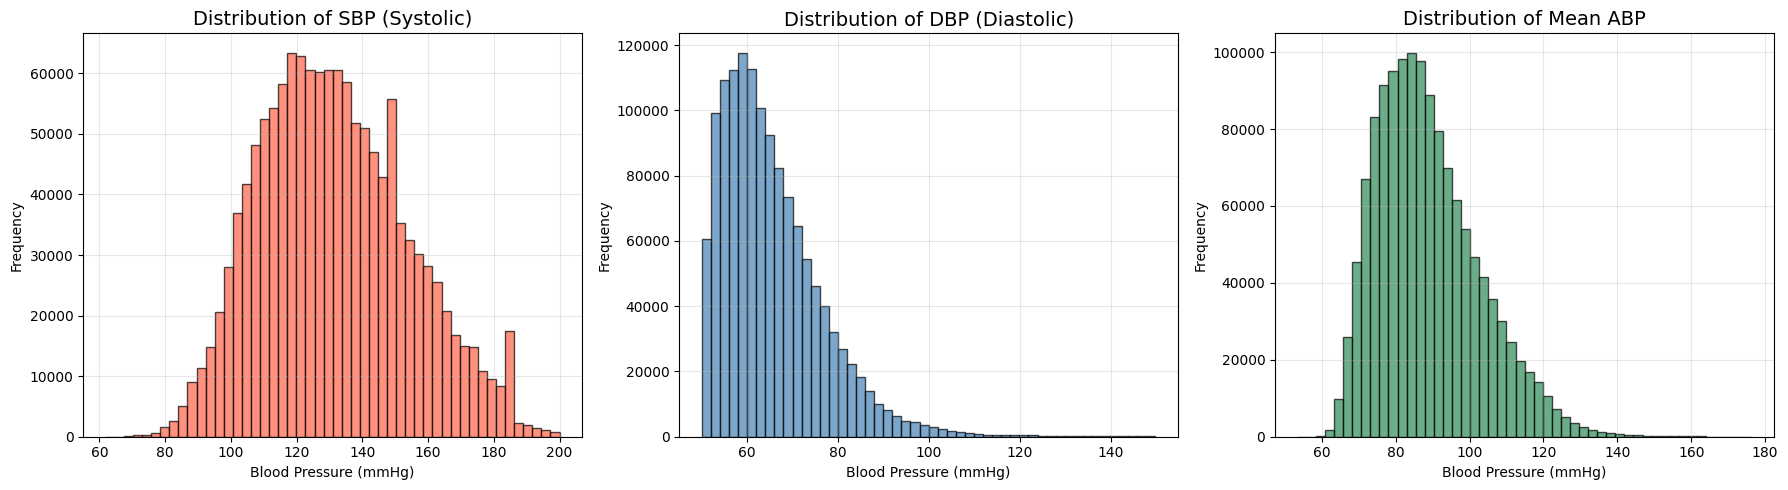

SBP  — Mean: 131.6, Std: 22.6, Range: [62.0, 200.0]
DBP  — Mean: 65.4, Std: 11.2, Range: [50.0, 149.9]
Mean — Mean: 88.8, Std: 13.9


In [5]:
# Tính SBP và DBP
sbp_values = np.array([seg.max() for seg in abp])
dbp_values = np.array([seg.min() for seg in abp])
mean_abp_values = abp.mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sbp_values, bins=50, color='tomato', edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of SBP (Systolic)", fontsize=14)
axes[0].set_xlabel("Blood Pressure (mmHg)")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)

axes[1].hist(dbp_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title("Distribution of DBP (Diastolic)", fontsize=14)
axes[1].set_xlabel("Blood Pressure (mmHg)")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

axes[2].hist(mean_abp_values, bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].set_title("Distribution of Mean ABP", fontsize=14)
axes[2].set_xlabel("Blood Pressure (mmHg)")
axes[2].set_ylabel("Frequency")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"SBP  — Mean: {sbp_values.mean():.1f}, Std: {sbp_values.std():.1f}, Range: [{sbp_values.min():.1f}, {sbp_values.max():.1f}]")
print(f"DBP  — Mean: {dbp_values.mean():.1f}, Std: {dbp_values.std():.1f}, Range: [{dbp_values.min():.1f}, {dbp_values.max():.1f}]")
print(f"Mean — Mean: {mean_abp_values.mean():.1f}, Std: {mean_abp_values.std():.1f}")


Cell 5 — Chuẩn bị features và target (SBP + DBP)

In [6]:
from sklearn.model_selection import GroupShuffleSplit

# Prepare features: PPG + ECG
X = np.stack((ppg, ecg), axis=-1).astype(np.float32) # Shape: (N, 250, 2)

# Target: SBP và DBP (2 outputs)
y_sbp = np.array([seg.max() for seg in abp]).reshape(-1, 1)
y_dbp = np.array([seg.min() for seg in abp]).reshape(-1, 1)
y = np.hstack([y_sbp, y_dbp]).astype(np.float32)  # Shape: (N, 2)



print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"group_ids shape: {group_ids.shape}")
print(f"SBP — mean: {y[:, 0].mean():.1f}, std: {y[:, 0].std():.1f}, range: [{y[:, 0].min():.1f}, {y[:, 0].max():.1f}]")
print(f"DBP — mean: {y[:, 1].mean():.1f}, std: {y[:, 1].std():.1f}, range: [{y[:, 1].min():.1f}, {y[:, 1].max():.1f}]")

# === Assertions ===
assert len(X) == len(y) == len(group_ids), "❌ Kích thước không khớp!"
assert not np.isnan(X).any(), "❌ X chứa NaN!"
assert not np.isnan(y).any(), "❌ y chứa NaN!"
assert (y[:, 0] > y[:, 1]).all(), "❌ Có samples SBP <= DBP!"
print("\n✅ Assertions passed — data sẵn sàng")

# Giải phóng RAM — không cần ppg, ecg, abp nữa
del ppg, ecg, abp, y_sbp, y_dbp
import gc; gc.collect()
print(f"Đã giải phóng RAM (ppg, ecg, abp)")

X shape: (1333867, 250, 2)
y shape: (1333867, 2)
group_ids shape: (1333867,)
SBP — mean: 131.6, std: 22.6, range: [62.0, 200.0]
DBP — mean: 65.4, std: 11.2, range: [50.0, 149.9]

✅ Assertions passed — data sẵn sàng
Đã giải phóng RAM (ppg, ecg, abp)


Cell 6 — Normalization

In [7]:
from sklearn.preprocessing import StandardScaler

# ============================================
# PER-SEGMENT PER-CHANNEL Z-SCORE cho X
# ============================================
# Mỗi segment (250 samples) × mỗi channel (PPG, ECG) 
# được chuẩn hóa ĐỘC LẬP → giữ nguyên dạng sóng

def normalize_per_segment(X):
    """
    X shape: (N, T, C) → output: (N, T, C)
    Mỗi segment, mỗi channel: (x - mean) / std
    """
    mean = X.mean(axis=1, keepdims=True)       # (N, 1, C)
    std = X.std(axis=1, keepdims=True) + 1e-8  # tránh chia 0
    return (X - mean) / std

X_scaled = normalize_per_segment(X).astype(np.float32)

# ============================================
# STANDARDSCALER cho y (SBP, DBP) — GIỮ NGUYÊN
# ============================================
# Chỉ 2 features (SBP, DBP), không có vấn đề std=0
scaler_y = StandardScaler().fit(y)
y_scaled = scaler_y.transform(y).astype(np.float32)

# === Kiểm tra ===
print(f"X_scaled shape: {X_scaled.shape}")
print(f"y_scaled shape: {y_scaled.shape}")
print(f"\n🔍 Sau normalization:")
print(f"   X — NaN: {np.isnan(X_scaled).sum()}, Inf: {np.isinf(X_scaled).sum()}")
print(f"   X — Mean: {X_scaled.mean():.6f}, Std: {X_scaled.std():.4f}")
print(f"   y — NaN: {np.isnan(y_scaled).sum()}, Inf: {np.isinf(y_scaled).sum()}")

assert not np.isnan(X_scaled).any(), "❌ X_scaled chứa NaN!"
assert not np.isinf(X_scaled).any(), "❌ X_scaled chứa Inf!"
assert not np.isnan(y_scaled).any(), "❌ y_scaled chứa NaN!"
print("✅ Normalization OK")

# Giải phóng X gốc
del X
gc.collect()
print(f"🧹 Đã giải phóng X gốc")


X_scaled shape: (1333867, 250, 2)
y_scaled shape: (1333867, 2)

🔍 Sau normalization:
   X — NaN: 0, Inf: 0
   X — Mean: -0.000000, Std: 1.0000
   y — NaN: 0, Inf: 0
✅ Normalization OK
🧹 Đã giải phóng X gốc


Cell 7 — Train/Test split

In [8]:
# ============================================
# SPLIT THEO RECORD (patient-level split)
# ============================================
# Tất cả segments từ cùng 1 record → cùng set (train HOẶC test)
# → Ngăn data leakage giữa các segments liền kề

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X_scaled, y_scaled, groups=group_ids))

X_train = X_scaled[train_idx]
X_test = X_scaled[test_idx]
y_train = y_scaled[train_idx]
y_test = y_scaled[test_idx]

# === Kiểm tra không overlap ===
train_groups = set(group_ids[train_idx])
test_groups = set(group_ids[test_idx])
overlap = train_groups & test_groups

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"\n📊 Split theo record:")
print(f"   Train records: {len(train_groups)}")
print(f"   Test records : {len(test_groups)}")
print(f"   Overlap      : {len(overlap)}")

assert len(overlap) == 0, "❌ Data leakage! Có record xuất hiện cả train và test!"
print("✅ Không có data leakage — split an toàn")


X_train: (935124, 250, 2), X_test: (398743, 250, 2)
y_train: (935124, 2), y_test: (398743, 2)

📊 Split theo record:
   Train records: 8400
   Test records : 3600
   Overlap      : 0
✅ Không có data leakage — split an toàn


Cell 8 — Xây dựng model (2 outputs: SBP + DBP) + Checkpoint setup

In [9]:
import json
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# ==== Cấu hình ====
TOTAL_EPOCHS = 25
BATCH_SIZE = 64
LEARNING_RATE = 5e-4
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
CHECKPOINT_PATH = f'{CHECKPOINT_DIR}/model_epoch_{{epoch:02d}}.keras'
HISTORY_PATH = f'{CHECKPOINT_DIR}/training_history.json'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def CNN_LSTM_Model_SBP_DBP(input_shape):
    model = Sequential([
        layers.Conv1D(filters=256, kernel_size=5, activation='relu',
                      input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        layers.LSTM(256, return_sequences=False),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),

        layers.Dense(2, activation='linear')
    ])
    return model

def find_latest_checkpoint(checkpoint_dir):
    import re
    checkpoints = glob.glob(f'{checkpoint_dir}/model_epoch_*.*')
    checkpoints = [c for c in checkpoints if c.endswith('.h5') or c.endswith('.keras')]
    if not checkpoints:
        return None, 0
    epochs = []
    for cp in checkpoints:
        match = re.search(r'model_epoch_(\d+)', cp)
        if match:
            epochs.append((int(match.group(1)), cp))
    if not epochs:
        return None, 0
    epochs.sort(key=lambda x: x[0])
    return epochs[-1][1], epochs[-1][0]

def load_training_history(history_path):
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            return json.load(f)
    return None

def save_training_history(history_dict, prev_history, history_path):
    if prev_history:
        merged = {key: prev_history.get(key, []) + history_dict[key] for key in history_dict}
    else:
        merged = history_dict
    with open(history_path, 'w') as f:
        json.dump(merged, f)
    return merged

# ==== Kiểm tra checkpoint ====
latest_checkpoint, last_epoch = find_latest_checkpoint(CHECKPOINT_DIR)

if latest_checkpoint and last_epoch < TOTAL_EPOCHS:
    print(f"🔄 Resume từ epoch {last_epoch}: {os.path.basename(latest_checkpoint)}")
    model = load_model(latest_checkpoint)
elif latest_checkpoint and last_epoch >= TOTAL_EPOCHS:
    print(f"✅ Đã hoàn tất ({last_epoch}/{TOTAL_EPOCHS} epochs)")
    model = load_model(latest_checkpoint)
else:
    print("🆕 Tạo model mới")
    model = CNN_LSTM_Model_SBP_DBP(input_shape=(sample_size, 2))
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss='mse',
        metrics=['mae']
    )
    last_epoch = 0

model.summary()
print(f"\n📌 Train từ epoch {last_epoch + 1} → {TOTAL_EPOCHS}")


2026-05-06 05:36:39.292626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778045799.489057      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778045799.544569      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778045800.027203      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778045800.027230      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778045800.027233      23 computation_placer.cc:177] computation placer alr

🆕 Tạo model mới


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778045820.072817      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778045820.078582      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 250, 256)       │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 125, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 125, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 125, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 62, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598,530 (2.28 MB)

 Trainable params: 596,482 (2.28 MB)

 Non-trainable params: 2,048 (8.00 KB)


📌 Train từ epoch 1 → 25


Cell 9 — Huấn luyện model (với checkpoint mỗi epoch)

In [10]:
import pandas as pd

# ==== Callbacks ====
callbacks = [
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        save_best_only=False,
        save_weights_only=False,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{CHECKPOINT_DIR}/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# ==== Load history trước đó ====
prev_history = load_training_history(HISTORY_PATH)

# ==== Train ====
if last_epoch < TOTAL_EPOCHS:
    remaining_epochs = TOTAL_EPOCHS - last_epoch
    print(f"\n🚀 Bắt đầu training: {remaining_epochs} epochs còn lại")
    print(f"   (epoch {last_epoch + 1} → {TOTAL_EPOCHS})\n")

    history_obj = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=TOTAL_EPOCHS,
        initial_epoch=last_epoch,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    full_history = save_training_history(history_obj.history, prev_history, HISTORY_PATH)
    print(f"\n✅ Training hoàn tất! ({len(full_history['loss'])} epochs)")
else:
    print("⏩ Đã hoàn tất trước đó — bỏ qua")
    full_history = prev_history

# ==== Lưu CSV ====
history_csv_path = f'{CHECKPOINT_DIR}/training_history.csv'
df_history = pd.DataFrame(full_history)
df_history.index = range(1, len(df_history) + 1)
df_history.index.name = 'epoch'
df_history.to_csv(history_csv_path)
print(f"📄 History CSV: {history_csv_path}")

# ==== In bảng ====
print("\n" + "=" * 85)
print("  📊 HISTORY TRAINING & VALIDATION")
print("=" * 85)
print(f"  {'Epoch':>5} | {'Train Loss':>12} | {'Val Loss':>12} | {'Train MAE':>12} | {'Val MAE':>12}")
print(f"  {'-' * 75}")
for i in range(len(full_history['loss'])):
    print(f"  {i+1:>5} | {full_history['loss'][i]:>12.4f} | {full_history['val_loss'][i]:>12.4f} | "
          f"{full_history['mae'][i]:>12.4f} | {full_history['val_mae'][i]:>12.4f}")
print("=" * 85)

best_epoch = int(np.argmin(full_history['val_loss'])) + 1
best_val_loss = min(full_history['val_loss'])
print(f"\n🏆 Best epoch: {best_epoch} (val_loss = {best_val_loss:.4f})")

class HistoryWrapper:
    def __init__(self, history_dict):
        self.history = history_dict

history = HistoryWrapper(full_history)



🚀 Bắt đầu training: 25 epochs còn lại
   (epoch 1 → 25)

Epoch 1/25


I0000 00:00:1778045830.701256      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


14612/14612 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7667 - mae: 0.6541
Epoch 1: saving model to /kaggle/working/checkpoints/model_epoch_01.keras

Epoch 1: val_loss improved from inf to 0.53959, saving model to /kaggle/working/checkpoints/best_model.keras
14612/14612 ━━━━━━━━━━━━━━━━━━━━ 331s 22ms/step - loss: 0.7667 - mae: 0.6541 - val_loss: 0.5396 - val_mae: 0.5159
Epoch 2/25
14610/14612 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3621 - mae: 0.4272
Epoch 2: saving model to /kaggle/working/checkpoints/model_epoch_02.keras

Epoch 2: val_loss improved from 0.53959 to 0.49397, saving model to /kaggle/working/checkpoints/best_model.keras
14612/14612 ━━━━━━━━━━━━━━━━━━━━ 320s 22ms/step - loss: 0.3621 - mae: 0.4272 - val_loss: 0.4940 - val_mae: 0.4836
Epoch 3/25
14612/14612 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2905 - mae: 0.3783
Epoch 3: saving model to /kaggle/working/checkpoints/model_epoch_03.keras

Epoch 3: val_loss improved from 0.49397 to 0.46358, saving model to /kaggle/wo

Cell 10 — Vẽ Training/Validation Loss & MAE

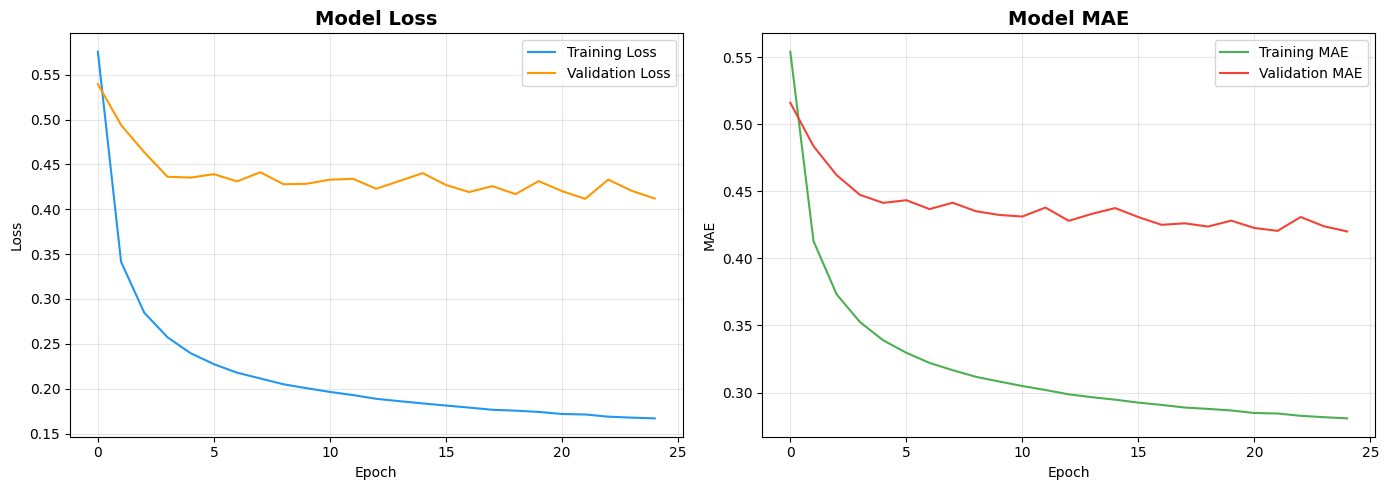

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#FF9800')
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE', color='#4CAF50')
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='#F44336')
axes[1].set_title('Model MAE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Cell 11 — Vẽ tổng hợp Loss & MAE trên cùng 1 hình

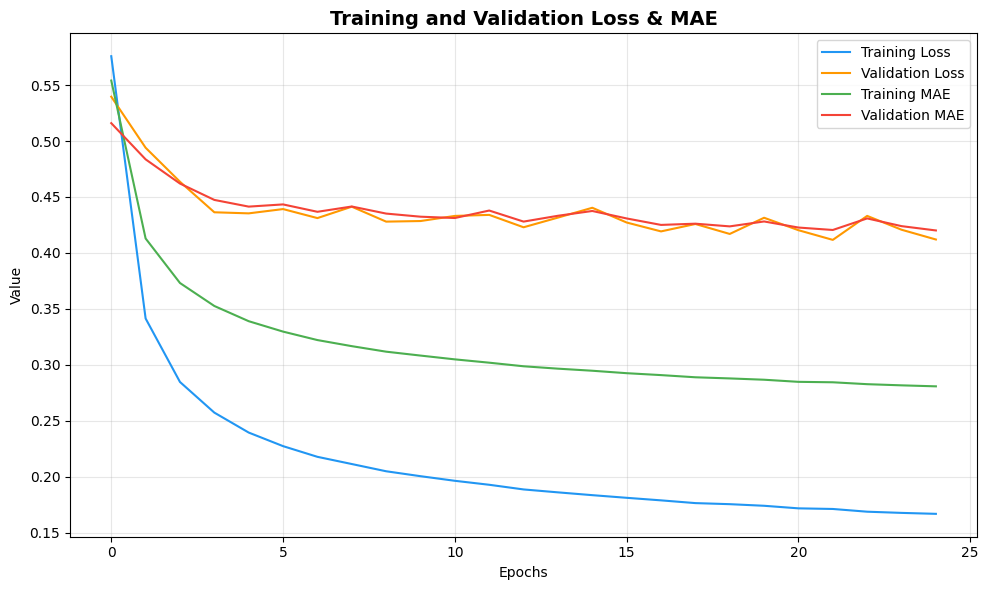

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='#2196F3')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#FF9800')
plt.plot(history.history['mae'], label='Training MAE', color='#4CAF50')
plt.plot(history.history['val_mae'], label='Validation MAE', color='#F44336')
plt.title('Training and Validation Loss & MAE', fontsize=14, fontweight='bold')
plt.ylabel('Value')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Cell 12 — Import metrics

In [13]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


Cell 13 — Đánh giá đầy đủ SBP + DBP (R², MAE, MSE, RMSE, ME, STD)

In [14]:
# ==== Dự đoán ====
# Dự đoán
preds_scaled = model.predict(X_test)

# Inverse transform về mmHg gốc
y_test_orig = scaler_y.inverse_transform(y_test)
preds_orig = scaler_y.inverse_transform(preds_scaled)

# Tách SBP và DBP
y_test_sbp = y_test_orig[:, 0]
y_test_dbp = y_test_orig[:, 1]
preds_sbp = preds_orig[:, 0]
preds_dbp = preds_orig[:, 1]

# ==== Hàm tính metrics ====
def compute_metrics(y_true, y_pred, name=""):
    """Tính đầy đủ 6 chỉ số đánh giá"""
    errors = y_pred - y_true

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    me = np.mean(errors)       # Mean Error (bias)
    std = np.std(errors)       # Standard Deviation of errors

    print(f"\n{'='*55}")
    print(f"  📊 Đánh giá {name}")
    print(f"{'='*55}")
    print(f"  R²     : {r2:.4f}")
    print(f"  MAE    : {mae:.2f} mmHg")
    print(f"  MSE    : {mse:.2f} mmHg²")
    print(f"  RMSE   : {rmse:.2f} mmHg")
    print(f"  ME     : {me:.2f} mmHg (bias)")
    print(f"  STD    : {std:.2f} mmHg")
    print(f"{'='*55}")

    # Kiểm tra tiêu chuẩn AAMI
    print(f"\n  📋 Kiểm tra tiêu chuẩn AAMI (|ME| ≤ 5, STD ≤ 8):")
    me_pass = "✅ ĐẠT" if abs(me) <= 5 else "❌ KHÔNG ĐẠT"
    std_pass = "✅ ĐẠT" if std <= 8 else "❌ KHÔNG ĐẠT"
    print(f"     |ME| = {abs(me):.2f} mmHg  → {me_pass}")
    print(f"     STD  = {std:.2f} mmHg  → {std_pass}")

    return {
        'R²': r2, 'MAE': mae, 'MSE': mse,
        'RMSE': rmse, 'ME': me, 'STD': std
    }

# ==== Tính metrics cho SBP và DBP ====
metrics_sbp = compute_metrics(y_test_sbp, preds_sbp, "SBP (Systolic BP)")
metrics_dbp = compute_metrics(y_test_dbp, preds_dbp, "DBP (Diastolic BP)")

# ==== Bảng tổng hợp ====
print("\n\n" + "=" * 60)
print("  📊 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ")
print("=" * 60)
print(f"  {'Metric':<10} {'SBP':>20} {'DBP':>20}")
print(f"  {'-' * 50}")
for key in ['R²', 'MAE', 'MSE', 'RMSE', 'ME', 'STD']:
    unit = " mmHg" if key not in ('R²', 'MSE') else ""
    if key == 'MSE':
        unit = " mmHg²"
    fmt = ".4f" if key == 'R²' else ".2f"
    sbp_str = f"{metrics_sbp[key]:{fmt}}{unit}"
    dbp_str = f"{metrics_dbp[key]:{fmt}}{unit}"
    print(f"  {key:<10} {sbp_str:>20} {dbp_str:>20}")
print("=" * 60)

# ==== Lưu kết quả test ra CSV ====
test_results = pd.DataFrame({
    'Metric': ['R²', 'MAE (mmHg)', 'MSE (mmHg²)', 'RMSE (mmHg)', 'ME (mmHg)', 'STD (mmHg)'],
    'SBP': [metrics_sbp['R²'], metrics_sbp['MAE'], metrics_sbp['MSE'],
            metrics_sbp['RMSE'], metrics_sbp['ME'], metrics_sbp['STD']],
    'DBP': [metrics_dbp['R²'], metrics_dbp['MAE'], metrics_dbp['MSE'],
            metrics_dbp['RMSE'], metrics_dbp['ME'], metrics_dbp['STD']]
})
test_csv_path = f'{CHECKPOINT_DIR}/test_results.csv'
test_results.to_csv(test_csv_path, index=False)
print(f"\n📄 Kết quả test đã lưu: {test_csv_path}")


12461/12461 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step

  📊 Đánh giá SBP (Systolic BP)
  R²     : 0.6449
  MAE    : 9.20 mmHg
  MSE    : 182.26 mmHg²
  RMSE   : 13.50 mmHg
  ME     : -1.04 mmHg (bias)
  STD    : 13.46 mmHg

  📋 Kiểm tra tiêu chuẩn AAMI (|ME| ≤ 5, STD ≤ 8):
     |ME| = 1.04 mmHg  → ✅ ĐẠT
     STD  = 13.46 mmHg  → ❌ KHÔNG ĐẠT

  📊 Đánh giá DBP (Diastolic BP)
  R²     : 0.5230
  MAE    : 4.84 mmHg
  MSE    : 58.32 mmHg²
  RMSE   : 7.64 mmHg
  ME     : -0.64 mmHg (bias)
  STD    : 7.61 mmHg

  📋 Kiểm tra tiêu chuẩn AAMI (|ME| ≤ 5, STD ≤ 8):
     |ME| = 0.64 mmHg  → ✅ ĐẠT
     STD  = 7.61 mmHg  → ✅ ĐẠT


  📊 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ
  Metric                      SBP                  DBP
  --------------------------------------------------
  R²                       0.6449               0.5230
  MAE                   9.20 mmHg            4.84 mmHg
  MSE                182.26 mmHg²          58.32 mmHg²
  RMSE                 13.50 mmHg            7.64 mmHg
  ME                  

Cell 14 — Biểu đồ Huyết áp Thực tế vs Dự đoán (giống style train/val loss)

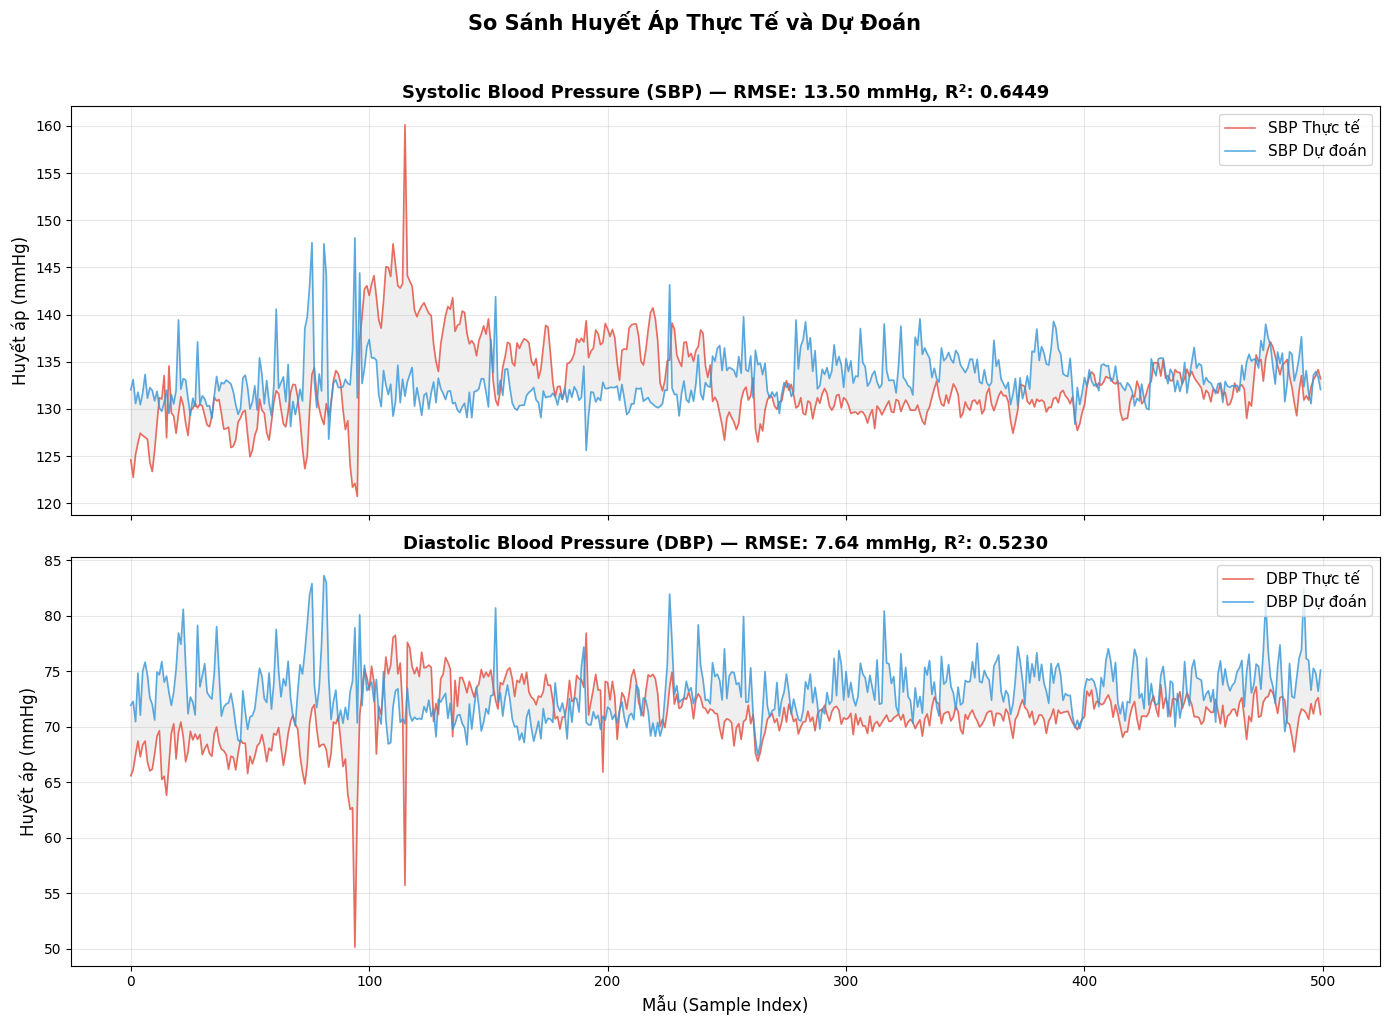

In [15]:
# Lấy N mẫu để hiển thị (giảm nếu quá nhiều)
n_display = min(500, len(y_test_sbp))
x_axis = np.arange(n_display)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- SBP ---
axes[0].plot(x_axis, y_test_sbp[:n_display], label='SBP Thực tế',
             color='#e74c3c', linewidth=1.2, alpha=0.8)
axes[0].plot(x_axis, preds_sbp[:n_display], label='SBP Dự đoán',
             color='#3498db', linewidth=1.2, alpha=0.8)
axes[0].fill_between(x_axis, y_test_sbp[:n_display], preds_sbp[:n_display],
                      alpha=0.12, color='gray')
axes[0].set_ylabel('Huyết áp (mmHg)', fontsize=12)
axes[0].set_title(
    f'Systolic Blood Pressure (SBP) — RMSE: {metrics_sbp["RMSE"]:.2f} mmHg, '
    f'R²: {metrics_sbp["R²"]:.4f}',
    fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='upper right')
axes[0].grid(True, alpha=0.3)

# --- DBP ---
axes[1].plot(x_axis, y_test_dbp[:n_display], label='DBP Thực tế',
             color='#e74c3c', linewidth=1.2, alpha=0.8)
axes[1].plot(x_axis, preds_dbp[:n_display], label='DBP Dự đoán',
             color='#3498db', linewidth=1.2, alpha=0.8)
axes[1].fill_between(x_axis, y_test_dbp[:n_display], preds_dbp[:n_display],
                      alpha=0.12, color='gray')
axes[1].set_ylabel('Huyết áp (mmHg)', fontsize=12)
axes[1].set_xlabel('Mẫu (Sample Index)', fontsize=12)
axes[1].set_title(
    f'Diastolic Blood Pressure (DBP) — RMSE: {metrics_dbp["RMSE"]:.2f} mmHg, '
    f'R²: {metrics_dbp["R²"]:.4f}',
    fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('So Sánh Huyết Áp Thực Tế và Dự Đoán',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted_bp.png', dpi=150, bbox_inches='tight')
plt.show()


Cell 15 — Scatter Plot (Thực tế vs Dự đoán)

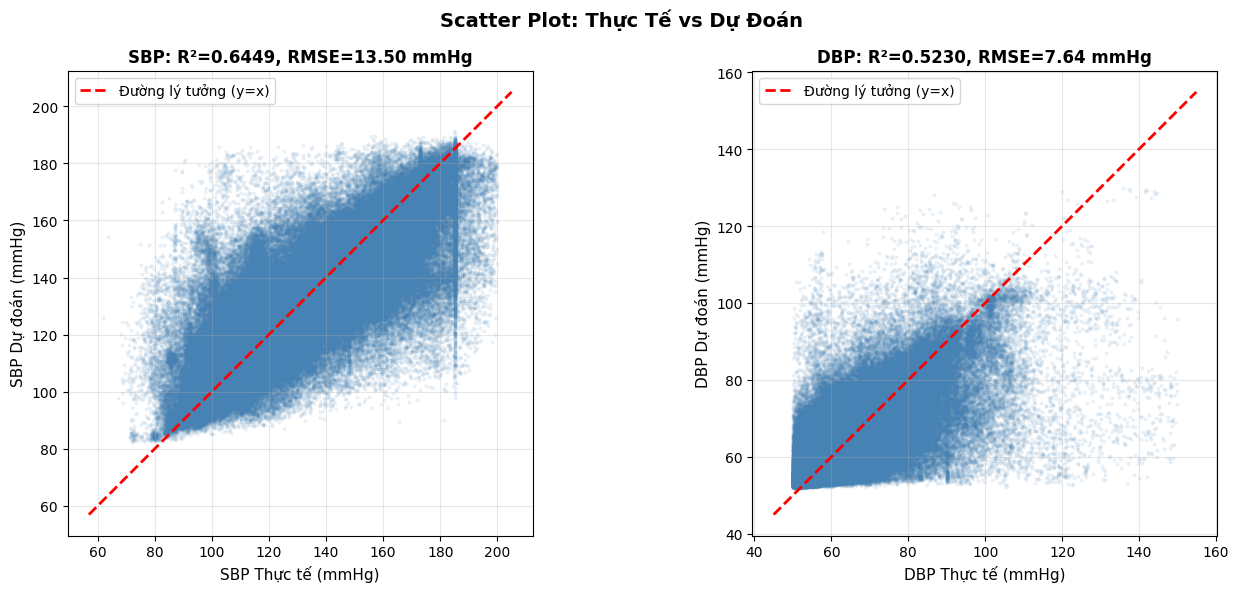

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_pred, name, metrics in [
    (axes[0], y_test_sbp, preds_sbp, 'SBP', metrics_sbp),
    (axes[1], y_test_dbp, preds_dbp, 'DBP', metrics_dbp)
]:
    ax.scatter(y_true, y_pred, alpha=0.08, s=4, color='steelblue')

    # Đường lý tưởng (y=x)
    lims = [min(y_true.min(), y_pred.min()) - 5,
            max(y_true.max(), y_pred.max()) + 5]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Đường lý tưởng (y=x)')

    ax.set_xlabel(f'{name} Thực tế (mmHg)', fontsize=11)
    ax.set_ylabel(f'{name} Dự đoán (mmHg)', fontsize=11)
    ax.set_title(
        f'{name}: R²={metrics["R²"]:.4f}, RMSE={metrics["RMSE"]:.2f} mmHg',
        fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Scatter Plot: Thực Tế vs Dự Đoán',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


Cell 16 — Bland-Altman Plot

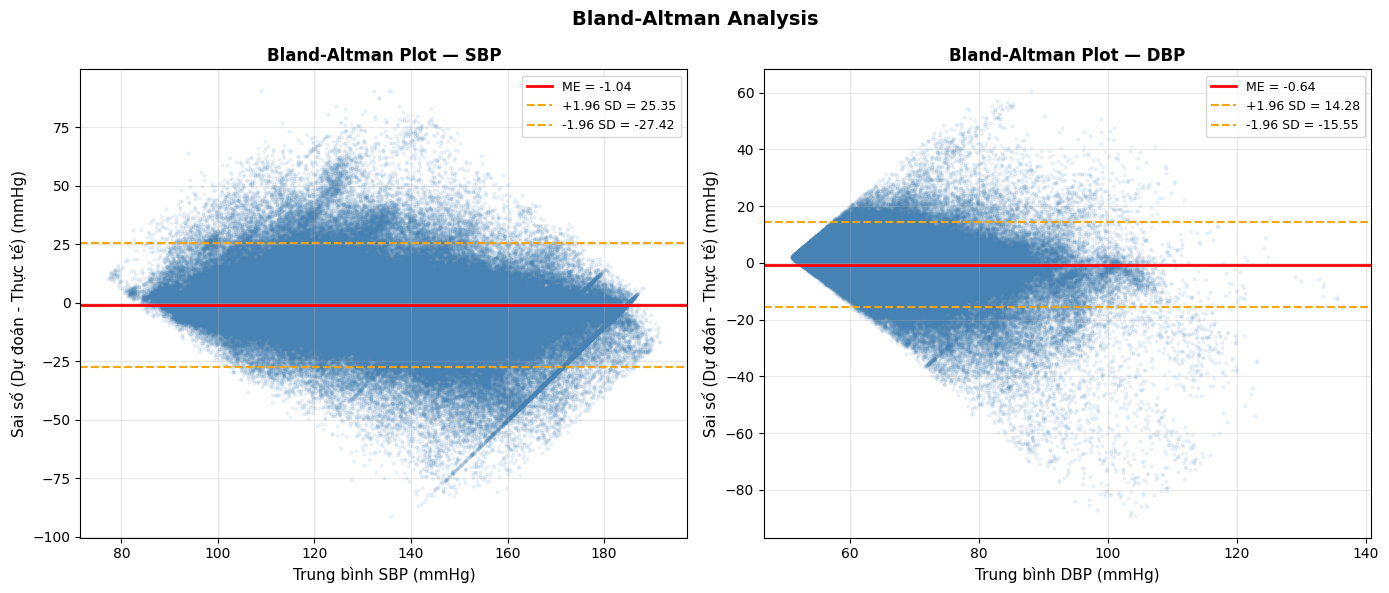

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_pred, name, metrics in [
    (axes[0], y_test_sbp, preds_sbp, 'SBP', metrics_sbp),
    (axes[1], y_test_dbp, preds_dbp, 'DBP', metrics_dbp)
]:
    mean_vals = (y_true + y_pred) / 2
    diff_vals = y_pred - y_true

    me = metrics['ME']
    std = metrics['STD']

    ax.scatter(mean_vals, diff_vals, alpha=0.08, s=4, color='steelblue')
    ax.axhline(y=me, color='red', linestyle='-', linewidth=2,
               label=f'ME = {me:.2f}')
    ax.axhline(y=me + 1.96 * std, color='orange', linestyle='--',
               linewidth=1.5, label=f'+1.96 SD = {me + 1.96 * std:.2f}')
    ax.axhline(y=me - 1.96 * std, color='orange', linestyle='--',
               linewidth=1.5, label=f'-1.96 SD = {me - 1.96 * std:.2f}')

    ax.set_xlabel(f'Trung bình {name} (mmHg)', fontsize=11)
    ax.set_ylabel(f'Sai số (Dự đoán - Thực tế) (mmHg)', fontsize=11)
    ax.set_title(f'Bland-Altman Plot — {name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Bland-Altman Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bland_altman_plot.png', dpi=150, bbox_inches='tight')
plt.show()


Cell 17 — Lưu model và scalers

In [18]:
model.save('CNN_LSTM_SBP_DBP.keras')
print("✅ Model đã được lưu: CNN_LSTM_SBP_DBP.keras")


✅ Model đã được lưu: CNN_LSTM_SBP_DBP.keras


Cell 18 — Lưu scalers

In [19]:
import pickle

with open('/kaggle/working/scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)

with open('/kaggle/working/scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)

print("✅ Scalers đã được lưu")


NameError: name 'scaler_X' is not defined

Cell 19 — Download link

In [ ]:
from IPython.display import FileLink
FileLink('CNN_LSTM_SBP_DBP.h5')
